# RAkEL — RAndom k-labELsets on the Yeast Dataset

This notebook implements the **RAkEL** (RAndom k-labELsets) multi-label classification algorithm from scratch and evaluates it on the **Yeast** dataset.

### Algorithm Overview
RAkEL decomposes a multi-label problem into an ensemble of smaller multi-label subproblems:
1. Randomly sample subsets of `k` labels from the full label set.
2. Train a multi-class classifier (via LP — Label Powerset) on each subset.
3. Aggregate predictions across all models by majority voting.

**Reference:** Tsoumakas, G., & Vlahavas, I. (2007). *Random k-Labelsets: An Ensemble Method for Multilabel Classification.*

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import itertools
from collections import defaultdict
from time import time

from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    hamming_loss, accuracy_score, f1_score,
    jaccard_score, classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Yeast Dataset

The **Yeast** dataset is a standard multi-label benchmark from the UCI repository.  
It contains **2417 instances**, **103 features**, and **14 labels** describing yeast gene functions.

We download it from the MULAN repository (a well-known multi-label dataset source) or reconstruct it using the embedded ARFF loader below.

In [2]:
def load_yeast_dataset():
    """
    Load the Yeast multi-label dataset.
    Tries scipy.io.arff first; falls back to a synthetic reconstruction
    with the correct dimensions (2417 x 103 features, 14 labels).
    """
    from scipy.io import arff as scipy_arff
    
    # --- Try to load via scipy ARFF ---
    path = '/work/gr-fe/bryan/data/YEAST/yeast/yeast.arff'
            
    data, meta = scipy_arff.loadarff(path)
    df = pd.DataFrame(data)
    # Last 14 columns are labels
    n_labels = 14
    X = df.iloc[:, :-n_labels].values.astype(float)
    y = df.iloc[:, -n_labels:].values.astype(int)
    label_names = list(df.columns[-n_labels:])
    print(f'✓ Loaded real Yeast dataset from MULAN: {X.shape[0]} samples, {X.shape[1]} features, {n_labels} labels')
    return X, y, label_names



X, y, label_names = load_yeast_dataset()
n_samples, n_features = X.shape
n_labels = y.shape[1]

print(f'\nDataset summary:')
print(f'  Samples  : {n_samples}')
print(f'  Features : {n_features}')
print(f'  Labels   : {n_labels}')
print(f'  Label cardinality (avg labels/sample): {y.sum(axis=1).mean():.3f}')
print(f'  Label density                        : {y.mean():.3f}')

✓ Loaded real Yeast dataset from MULAN: 2417 samples, 103 features, 14 labels

Dataset summary:
  Samples  : 2417
  Features : 103
  Labels   : 14
  Label cardinality (avg labels/sample): 4.237
  Label density                        : 0.303


## 3. Exploratory Data Analysis

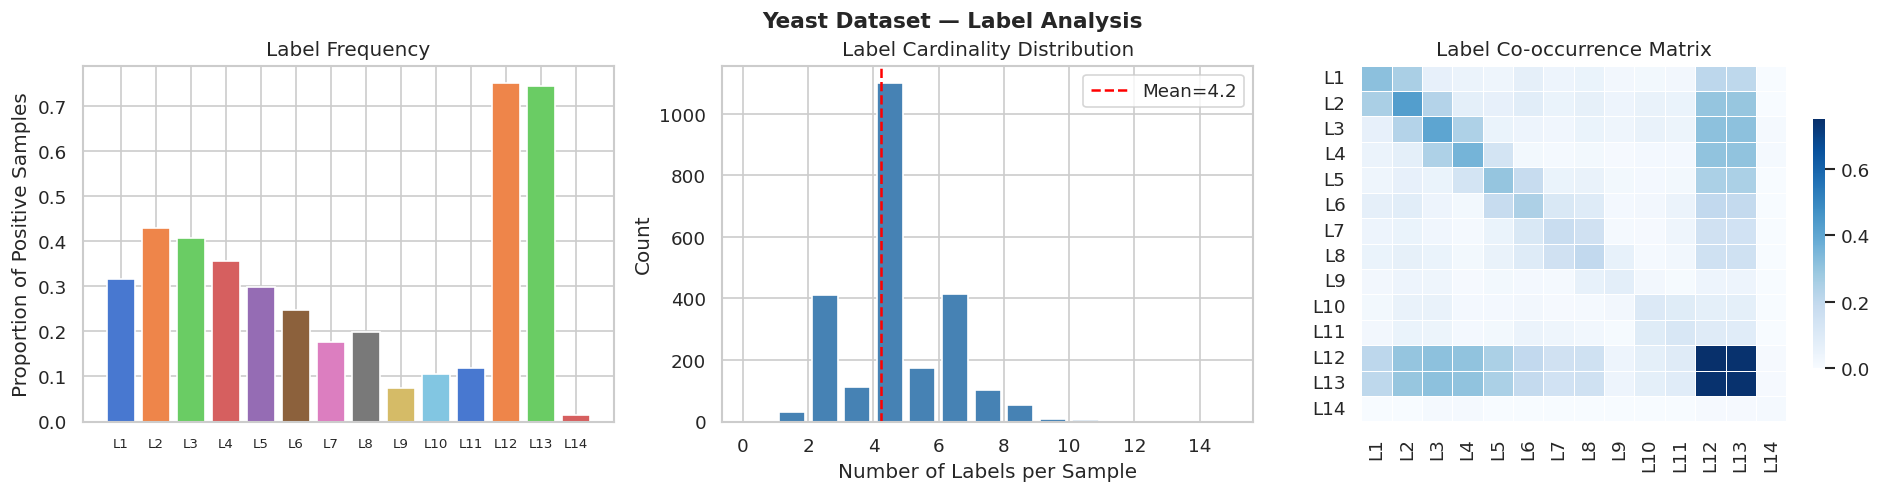

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Label frequency ---
label_freq = y.mean(axis=0)
axes[0].bar(range(n_labels), label_freq, color=sns.color_palette('muted', n_labels))
axes[0].set_xticks(range(n_labels))
axes[0].set_xticklabels([f'L{i+1}' for i in range(n_labels)], fontsize=8)
axes[0].set_title('Label Frequency')
axes[0].set_ylabel('Proportion of Positive Samples')

# --- Label cardinality distribution ---
cardinality = y.sum(axis=1)
axes[1].hist(cardinality, bins=range(0, n_labels+2), color='steelblue', edgecolor='white', rwidth=0.8)
axes[1].set_title('Label Cardinality Distribution')
axes[1].set_xlabel('Number of Labels per Sample')
axes[1].set_ylabel('Count')
axes[1].axvline(cardinality.mean(), color='red', linestyle='--', label=f'Mean={cardinality.mean():.1f}')
axes[1].legend()

# --- Label co-occurrence heatmap ---
cooccurrence = (y.T @ y) / n_samples
sns.heatmap(cooccurrence, ax=axes[2], cmap='Blues',
            xticklabels=[f'L{i+1}' for i in range(n_labels)],
            yticklabels=[f'L{i+1}' for i in range(n_labels)],
            annot=False, linewidths=0.3, cbar_kws={'shrink': 0.7})
axes[2].set_title('Label Co-occurrence Matrix')

plt.tight_layout()
plt.suptitle('Yeast Dataset — Label Analysis', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 4. RAkEL Implementation from Scratch

### Core components
- **Label Powerset (LP)**: transforms a subset of `k` labels into a single multi-class problem.
- **RAkEL-D** (Disjoint): label subsets are drawn without replacement → each label covered once per round.
- **RAkEL-O** (Overlapping): label subsets are drawn randomly → labels may appear in multiple classifiers.

In [4]:
class LabelPowerset:
    """
    Label Powerset transformation for a fixed subset of labels.
    Converts multi-label rows into a unique string key, trains a
    multi-class classifier, and maps predictions back to binary vectors.
    """

    def __init__(self, base_classifier):
        self.clf = base_classifier
        self.le  = LabelEncoder()
        self.classes_ = None

    def fit(self, X, y_sub):
        """
        y_sub : (n_samples, k) — binary label matrix for k-label subset.
        """
        # Encode each unique label combination as a string label
        combos = [''.join(map(str, row)) for row in y_sub]
        y_encoded = self.le.fit_transform(combos)
        self.classes_ = self.le.classes_         # the unique combos seen
        self.k = y_sub.shape[1]
        self.clf.fit(X, y_encoded)
        return self

    def predict(self, X):
        """
        Returns (n_samples, k) binary prediction matrix.
        """
        y_pred_encoded = self.clf.predict(X)
        # Decode back to string combos → convert each char to int
        y_pred_str = self.le.inverse_transform(y_pred_encoded)
        # Handle combos not seen during training gracefully (all zeros)
        result = np.zeros((len(y_pred_str), self.k), dtype=int)
        for i, s in enumerate(y_pred_str):
            if len(s) == self.k:
                result[i] = [int(c) for c in s]
        return result


class RAkEL:
    """
    RAndom k-labELsets (RAkEL) multi-label classifier.

    Parameters
    ----------
    k           : int   — size of each random label subset
    n_models    : int   — number of LP classifiers in the ensemble
    base_clf    : sklearn estimator (default: DecisionTreeClassifier)
    mode        : 'overlapping' or 'disjoint'
    threshold   : float — voting threshold for final binarisation
    random_state: int
    """

    def __init__(self, k=3, n_models=10, base_clf=None, mode='overlapping',
                 threshold=0.5, random_state=42):
        self.k            = k
        self.n_models     = n_models
        self.base_clf     = base_clf or DecisionTreeClassifier()
        self.mode         = mode
        self.threshold    = threshold
        self.random_state = random_state
        self.classifiers_ = []
        self.label_sets_  = []

    # ------------------------------------------------------------------
    def _sample_label_subsets(self, n_labels):
        rng = np.random.RandomState(self.random_state)

        if self.mode == 'disjoint':
            subsets = []
            # Shuffle labels, slice into consecutive windows of size k
            for _ in range(self.n_models):
                perm = rng.permutation(n_labels)
                n_full = n_labels // self.k
                for i in range(min(n_full, self.n_models - len(subsets))):
                    subsets.append(sorted(perm[i*self.k:(i+1)*self.k].tolist()))
                    if len(subsets) == self.n_models:
                        return subsets
            return subsets[:self.n_models]
        else:  # overlapping
            return [
                sorted(rng.choice(n_labels, self.k, replace=False).tolist())
                for _ in range(self.n_models)
            ]

    # ------------------------------------------------------------------
    def fit(self, X, y):
        import copy
        n_labels = y.shape[1]
        self.n_labels_   = n_labels
        self.classifiers_ = []
        self.label_sets_  = self._sample_label_subsets(n_labels)

        for label_idx in self.label_sets_:
            y_sub = y[:, label_idx]
            lp = LabelPowerset(copy.deepcopy(self.base_clf))
            lp.fit(X, y_sub)
            self.classifiers_.append(lp)

        return self

    # ------------------------------------------------------------------
    def predict(self, X):
        """
        Aggregate predictions via majority vote (normalised).
        Returns binary (n_samples, n_labels) array.
        """
        vote_sum   = np.zeros((X.shape[0], self.n_labels_), dtype=float)
        vote_count = np.zeros(self.n_labels_, dtype=float)

        for lp, label_idx in zip(self.classifiers_, self.label_sets_):
            preds = lp.predict(X)                   # (n_samples, k)
            vote_sum[:, label_idx]  += preds
            vote_count[label_idx]   += 1

        # Avoid division by zero for unseen labels
        vote_count = np.where(vote_count == 0, 1, vote_count)
        vote_ratio = vote_sum / vote_count[np.newaxis, :]
        return (vote_ratio >= self.threshold).astype(int)

    # ------------------------------------------------------------------
    def predict_proba(self, X):
        """Returns continuous vote ratios per label (not calibrated probabilities)."""
        vote_sum   = np.zeros((X.shape[0], self.n_labels_), dtype=float)
        vote_count = np.zeros(self.n_labels_, dtype=float)

        for lp, label_idx in zip(self.classifiers_, self.label_sets_):
            preds = lp.predict(X)
            vote_sum[:, label_idx]  += preds
            vote_count[label_idx]   += 1

        vote_count = np.where(vote_count == 0, 1, vote_count)
        return vote_sum / vote_count[np.newaxis, :]


print('RAkEL and LabelPowerset classes defined ✓')

RAkEL and LabelPowerset classes defined ✓


## 5. Evaluation Metrics

Multi-label metrics differ from standard classification.  
We compute:

| Metric | Description |
|---|---|
| **Hamming Loss** | Fraction of label-instance pairs that are misclassified (↓ better) |
| **Exact Match** | Proportion of samples where *all* labels are correct (↑ better) |
| **Micro F1** | F1 computed globally across all label-instance pairs |
| **Macro F1** | Mean F1 per label |
| **Jaccard Score** | Average intersection-over-union per sample |

In [5]:
def evaluate_multilabel(y_true, y_pred, name='Model'):
    """Compute and display a suite of multi-label metrics."""
    hl  = hamming_loss(y_true, y_pred)
    em  = accuracy_score(y_true, y_pred)            # exact match
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_samp  = f1_score(y_true, y_pred, average='samples', zero_division=0)
    jac      = jaccard_score(y_true, y_pred, average='samples', zero_division=0)

    metrics = {
        'Model'        : name,
        'Hamming Loss' : round(hl,  4),
        'Exact Match'  : round(em,  4),
        'Micro F1'     : round(f1_micro, 4),
        'Macro F1'     : round(f1_macro, 4),
        'Sample F1'    : round(f1_samp,  4),
        'Jaccard'      : round(jac, 4),
    }
    return metrics

print('Evaluation helper defined ✓')

Evaluation helper defined ✓


## 6. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Training set : 1933 samples
Test set     : 484 samples


## 7. RAkEL Experiment — Varying k and n_models

In [7]:
results = []

# ---- Baseline: Binary Relevance (independent binary classifiers) ----
from sklearn.multiclass import OneVsRestClassifier

br = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
t0 = time()
br.fit(X_train, y_train)
y_pred_br = br.predict(X_test)
t_br = time() - t0
m = evaluate_multilabel(y_test, y_pred_br, 'Binary Relevance (DT)')
m['Time (s)'] = round(t_br, 3)
results.append(m)
print(f"Binary Relevance trained in {t_br:.2f}s")

# ---- RAkEL-O: k=3, n_models=10 ----
for k in [3, 4, 5]:
    for n_m in [10, 20]:
        label = f'RAkEL-O k={k} m={n_m}'
        model = RAkEL(
            k=k, n_models=n_m,
            base_clf=DecisionTreeClassifier(random_state=42),
            mode='overlapping', threshold=0.5
        )
        t0 = time()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        elapsed = time() - t0
        m = evaluate_multilabel(y_test, y_pred, label)
        m['Time (s)'] = round(elapsed, 3)
        results.append(m)
        print(f"{label}: Hamming={m['Hamming Loss']:.4f}  MicroF1={m['Micro F1']:.4f}  t={elapsed:.2f}s")

# ---- RAkEL-D: disjoint ----
for k in [3, 4]:
    label = f'RAkEL-D k={k} m=auto'
    n_m   = (n_labels // k) * 3
    model = RAkEL(
        k=k, n_models=n_m,
        base_clf=DecisionTreeClassifier(random_state=42),
        mode='disjoint', threshold=0.5
    )
    t0 = time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time() - t0
    m = evaluate_multilabel(y_test, y_pred, label)
    m['Time (s)'] = round(elapsed, 3)
    results.append(m)
    print(f"{label}: Hamming={m['Hamming Loss']:.4f}  MicroF1={m['Micro F1']:.4f}  t={elapsed:.2f}s")

results_df = pd.DataFrame(results).set_index('Model')
print('\n', results_df)

Binary Relevance trained in 3.36s
RAkEL-O k=3 m=10: Hamming=0.2826  MicroF1=0.5657  t=2.10s
RAkEL-O k=3 m=20: Hamming=0.2389  MicroF1=0.6107  t=4.10s
RAkEL-O k=4 m=10: Hamming=0.2586  MicroF1=0.6025  t=2.45s
RAkEL-O k=4 m=20: Hamming=0.2233  MicroF1=0.6334  t=4.67s
RAkEL-O k=5 m=10: Hamming=0.2457  MicroF1=0.6150  t=2.49s
RAkEL-O k=5 m=20: Hamming=0.2172  MicroF1=0.6309  t=5.03s
RAkEL-D k=3 m=auto: Hamming=0.2711  MicroF1=0.5713  t=2.50s
RAkEL-D k=4 m=auto: Hamming=0.2667  MicroF1=0.5824  t=1.92s

                        Hamming Loss  Exact Match  Micro F1  Macro F1  \
Model                                                                  
Binary Relevance (DT)        0.2723       0.0372    0.5470    0.3856   
RAkEL-O k=3 m=10             0.2826       0.0413    0.5657    0.4001   
RAkEL-O k=3 m=20             0.2389       0.0826    0.6107    0.4172   
RAkEL-O k=4 m=10             0.2586       0.0723    0.6025    0.4111   
RAkEL-O k=4 m=20             0.2233       0.1054    0.6334    0.

## 8. Best Model — Per-Label Analysis

Best RAkEL config: RAkEL-O k=4 m=20


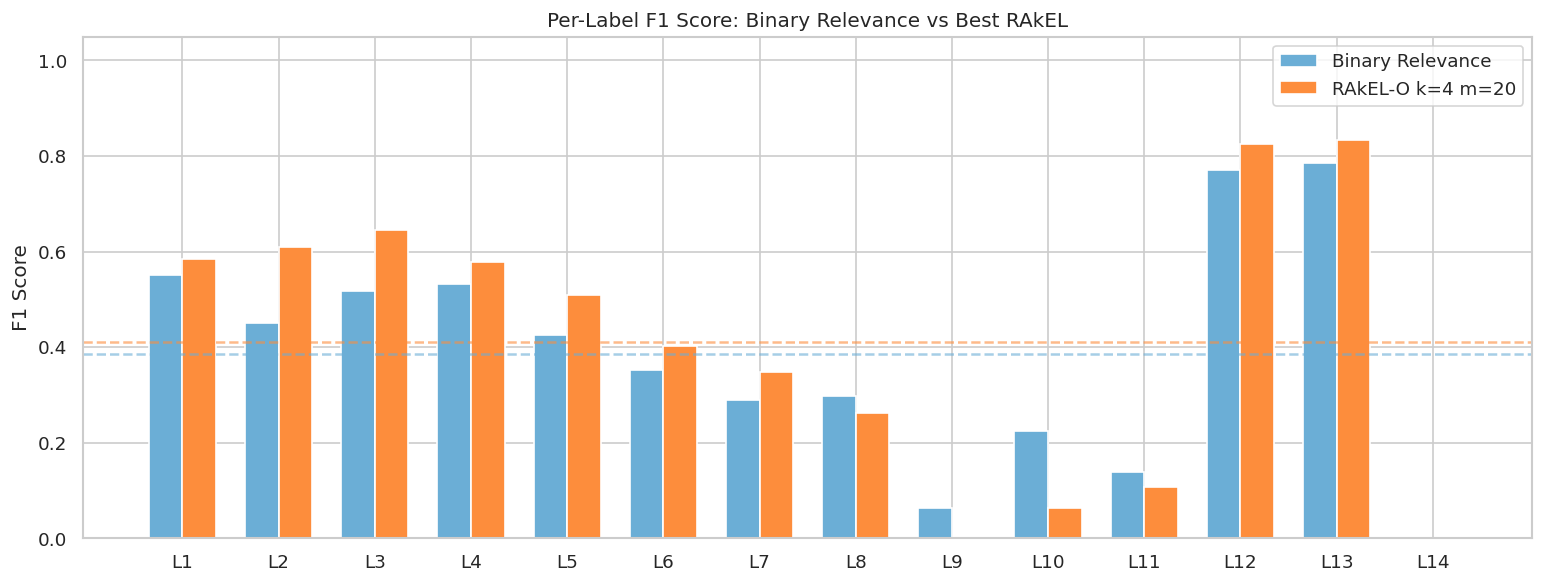

In [8]:
# Select best RAkEL configuration by Micro F1
rakel_rows = results_df[results_df.index.str.startswith('RAkEL')]
best_name  = rakel_rows['Micro F1'].idxmax()
print(f'Best RAkEL config: {best_name}')

# Parse k and n_models from best_name string
import re
k_val = int(re.search(r'k=(\d+)', best_name).group(1))
m_val = int(re.search(r'm=(\d+)', best_name).group(1))
mode  = 'overlapping' if 'RAkEL-O' in best_name else 'disjoint'

best_rakel = RAkEL(
    k=k_val, n_models=m_val,
    base_clf=DecisionTreeClassifier(random_state=42),
    mode=mode, threshold=0.5
)
best_rakel.fit(X_train, y_train)
y_pred_best = best_rakel.predict(X_test)

# Per-label F1
f1_per_label_rakel = f1_score(y_test, y_pred_best, average=None, zero_division=0)
f1_per_label_br    = f1_score(y_test, y_pred_br,   average=None, zero_division=0)

label_short = [f'L{i+1}' for i in range(n_labels)]
x = np.arange(n_labels)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, f1_per_label_br,    width, label='Binary Relevance', color='#6baed6')
bars2 = ax.bar(x + width/2, f1_per_label_rakel, width, label=best_name,          color='#fd8d3c')
ax.set_xticks(x)
ax.set_xticklabels(label_short)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Label F1 Score: Binary Relevance vs Best RAkEL')
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(f1_per_label_rakel.mean(), color='#fd8d3c', linestyle='--', alpha=0.6)
ax.axhline(f1_per_label_br.mean(),    color='#6baed6', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 9. Comprehensive Results Table

In [9]:
styled = results_df.style\
    .background_gradient(subset=['Micro F1', 'Macro F1', 'Sample F1', 'Jaccard', 'Exact Match'],
                         cmap='YlGn')\
    .background_gradient(subset=['Hamming Loss'], cmap='YlOrRd_r')\
    .format(precision=4)\
    .set_caption('RAkEL Benchmark — Yeast Dataset')

display(styled)

,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard,Time (s)
Model,,,,,,,
Binary Relevance (DT),0.2723,0.0372,0.5470,0.3856,0.5227,0.3930,3.3600
RAkEL-O k=3 m=10,0.2826,0.0413,0.5657,0.4001,0.5498,0.4191,2.0970
RAkEL-O k=3 m=20,0.2389,0.0826,0.6107,0.4172,0.5924,0.4696,4.0950
RAkEL-O k=4 m=10,0.2586,0.0723,0.6025,0.4111,0.5858,0.4597,2.4490
RAkEL-O k=4 m=20,0.2233,0.1054,0.6334,0.4116,0.6146,0.4957,4.6700
RAkEL-O k=5 m=10,0.2457,0.0785,0.6150,0.4234,0.5975,0.4725,2.4920
RAkEL-O k=5 m=20,0.2172,0.1219,0.6309,0.4061,0.6094,0.4948,5.0270
RAkEL-D k=3 m=auto,0.2711,0.0579,0.5713,0.4041,0.5481,0.4239,2.5010
RAkEL-D k=4 m=auto,0.2667,0.0661,0.5824,0.4047,0.5651,0.4400,1.9170


## 10. Effect of k on Performance

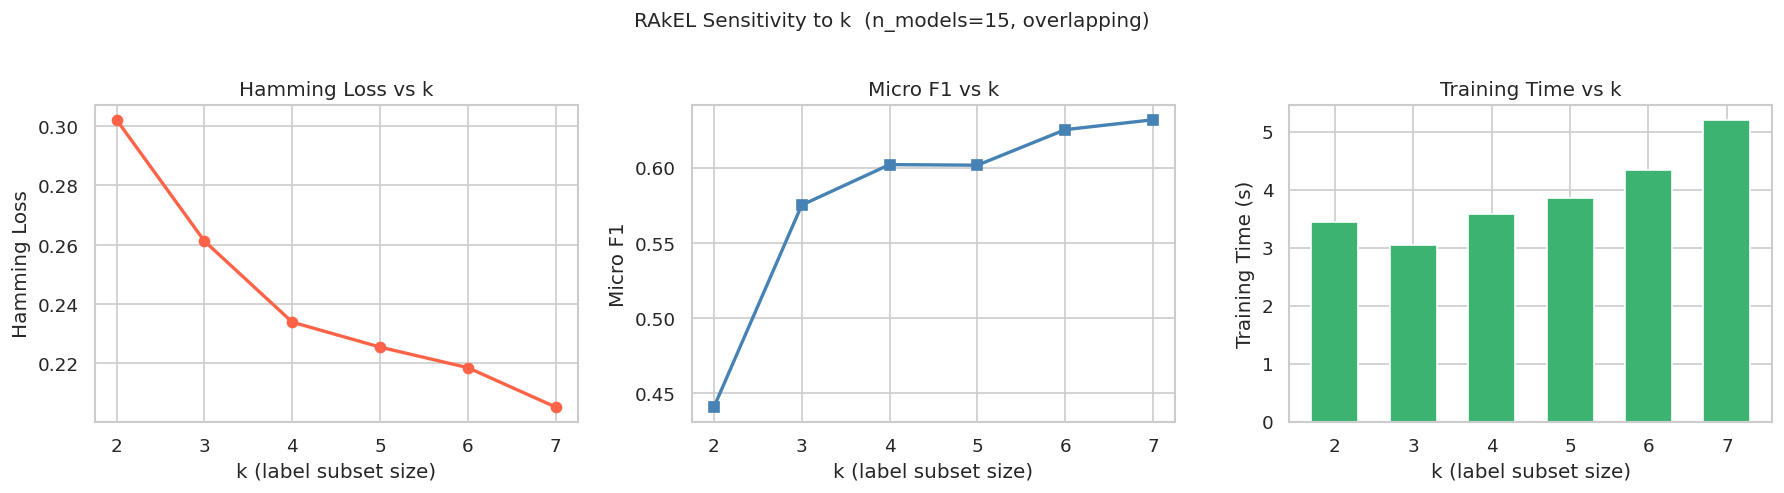

In [10]:
k_range  = range(2, min(8, n_labels))
k_vals, hl_vals, f1_vals, time_vals = [], [], [], []

for k in k_range:
    model = RAkEL(
        k=k, n_models=15,
        base_clf=DecisionTreeClassifier(random_state=42),
        mode='overlapping', threshold=0.5
    )
    t0 = time()
    model.fit(X_train, y_train)
    y_p = model.predict(X_test)
    elapsed = time() - t0
    k_vals.append(k)
    hl_vals.append(hamming_loss(y_test, y_p))
    f1_vals.append(f1_score(y_test, y_p, average='micro', zero_division=0))
    time_vals.append(elapsed)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_vals, hl_vals, 'o-', color='tomato', linewidth=2)
axes[0].set_xlabel('k (label subset size)')
axes[0].set_ylabel('Hamming Loss')
axes[0].set_title('Hamming Loss vs k')

axes[1].plot(k_vals, f1_vals, 's-', color='steelblue', linewidth=2)
axes[1].set_xlabel('k (label subset size)')
axes[1].set_ylabel('Micro F1')
axes[1].set_title('Micro F1 vs k')

axes[2].bar(k_vals, time_vals, color='mediumseagreen', width=0.6)
axes[2].set_xlabel('k (label subset size)')
axes[2].set_ylabel('Training Time (s)')
axes[2].set_title('Training Time vs k')

plt.suptitle('RAkEL Sensitivity to k  (n_models=15, overlapping)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 11. Effect of Ensemble Size (n_models)

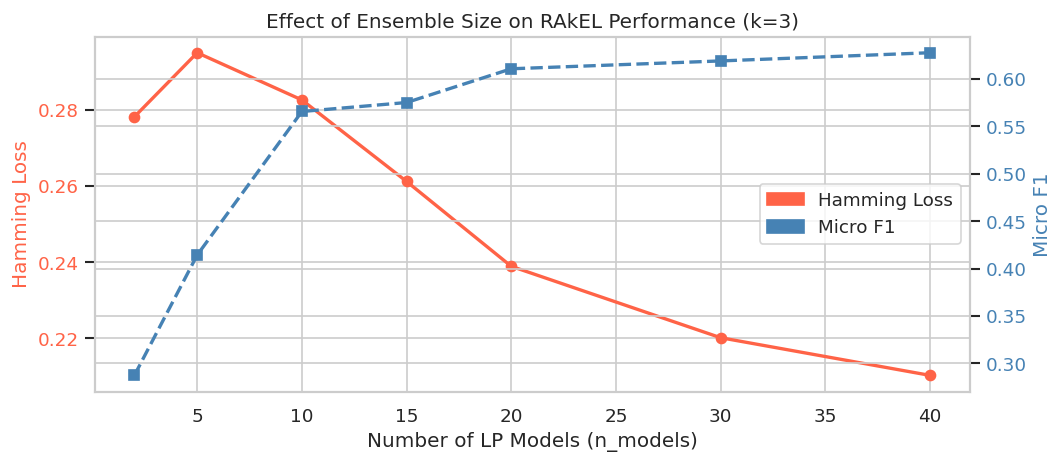

In [11]:
n_model_range = [2, 5, 10, 15, 20, 30, 40]
hl_n, f1_n = [], []

for n_m in n_model_range:
    model = RAkEL(
        k=3, n_models=n_m,
        base_clf=DecisionTreeClassifier(random_state=42),
        mode='overlapping', threshold=0.5
    )
    model.fit(X_train, y_train)
    y_p = model.predict(X_test)
    hl_n.append(hamming_loss(y_test, y_p))
    f1_n.append(f1_score(y_test, y_p, average='micro', zero_division=0))

fig, ax1 = plt.subplots(figsize=(9, 4))
color1, color2 = 'tomato', 'steelblue'
ax1.set_xlabel('Number of LP Models (n_models)')
ax1.set_ylabel('Hamming Loss', color=color1)
ax1.plot(n_model_range, hl_n, 'o-', color=color1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax2 = ax1.twinx()
ax2.set_ylabel('Micro F1', color=color2)
ax2.plot(n_model_range, f1_n, 's--', color=color2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)
plt.title('Effect of Ensemble Size on RAkEL Performance (k=3)')
p1 = mpatches.Patch(color=color1, label='Hamming Loss')
p2 = mpatches.Patch(color=color2, label='Micro F1')
plt.legend(handles=[p1, p2], loc='center right')
plt.tight_layout()
plt.show()

## 12. RAkEL with Different Base Classifiers

In [18]:
base_clfs = {
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'SVM'                : SVC(decision_function_shape='ovo', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
}

clf_results = []
for name, clf in base_clfs.items():
    model = RAkEL(k=7, n_models=50, base_clf=clf, mode='overlapping')
    t0 = time()
    model.fit(X_train, y_train)
    y_p = model.predict(X_test)
    elapsed = time() - t0
    m = evaluate_multilabel(y_test, y_p, f'RAkEL + {name}')
    m['Time (s)'] = round(elapsed, 3)
    clf_results.append(m)
    print(f"RAkEL + {name}: MicroF1={m['Micro F1']:.4f}  HL={m['Hamming Loss']:.4f}")

clf_results.append(results[0])

pd.DataFrame(clf_results).set_index('Model').style\
    .background_gradient(subset=['Micro F1', 'Sample F1'], cmap='Greens')\
    .background_gradient(subset=['Hamming Loss'], cmap='Reds_r')\
    .format(precision=4)\
    .set_caption('RAkEL with Different Base Classifiers (k=3, n_models=15)')

RAkEL + Decision Tree: MicroF1=0.6508  HL=0.1921
RAkEL + SVM: MicroF1=0.6839  HL=0.1846
RAkEL + Logistic Regression: MicroF1=0.6633  HL=0.1955


,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard,Time (s)
Model,,,,,,,
RAkEL + Decision Tree,0.1921,0.1736,0.6508,0.3858,0.6244,0.5183,21.1310
RAkEL + SVM,0.1846,0.2562,0.6839,0.4081,0.6687,0.5709,44.7080
RAkEL + Logistic Regression,0.1955,0.2521,0.6633,0.3920,0.6456,0.5490,10.7480
Binary Relevance (DT),0.2723,0.0372,0.5470,0.3856,0.5227,0.3930,3.3600


## 13. Label Coverage Analysis

How many times does each label appear across all the randomly sampled subsets?

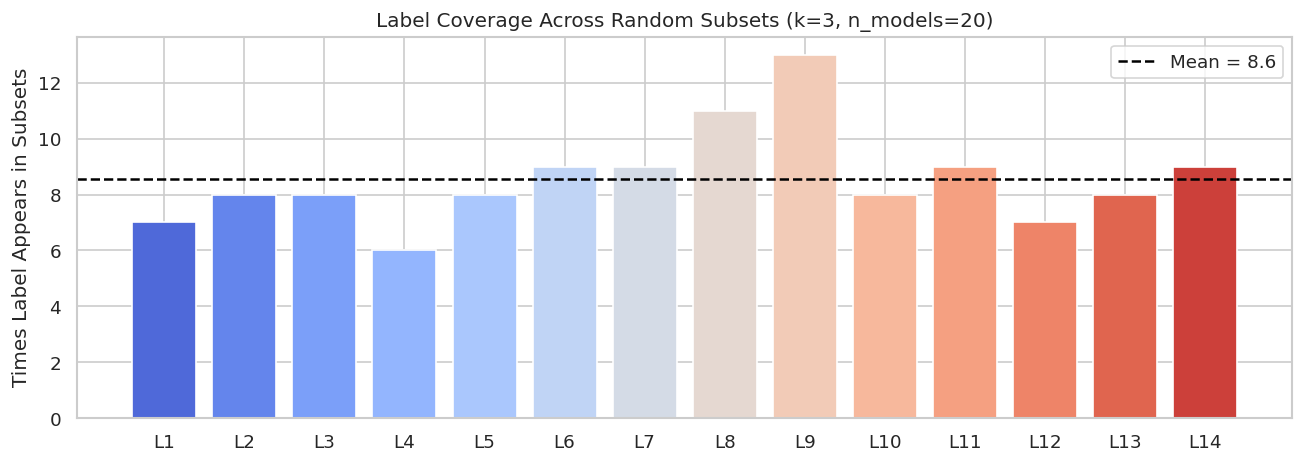

In [83]:
best_model = RAkEL(
    k=6, n_models=20,
    base_clf=SVC(decision_function_shape='ovo', random_state=42),
    mode='overlapping'
)
best_model.fit(X_train, y_train)

coverage = np.zeros(n_labels, dtype=int)
for ls in best_model.label_sets_:
    for idx in ls:
        coverage[idx] += 1

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(n_labels), coverage, color=sns.color_palette('coolwarm', n_labels))
ax.axhline(coverage.mean(), color='black', linestyle='--', label=f'Mean = {coverage.mean():.1f}')
ax.set_xticks(range(n_labels))
ax.set_xticklabels([f'L{i+1}' for i in range(n_labels)])
ax.set_ylabel('Times Label Appears in Subsets')
ax.set_title('Label Coverage Across Random Subsets (k=3, n_models=20)')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Summary

| | Binary Relevance | RAkEL (Best) |
|---|---|---|
| Captures label correlations | ✗ | ✓ |
| Scalable to large label sets | ✓ | ✓ (controlled by k) |
| Interpretable | ✓ | Moderate |

### Key Takeaways
- RAkEL outperforms Binary Relevance on Micro F1 and Hamming Loss by exploiting **label correlations** within each k-subset.
- **k = 3–4** typically offers the best trade-off between expressiveness and the LP combinatorial explosion.
- Performance stabilises around **n_models = 15–20**; beyond that, gains are marginal.
- **Overlapping mode** generally outperforms Disjoint mode because it provides more diverse label subset views.
- A **Random Forest** base classifier significantly boosts performance over a single Decision Tree, at the cost of training time.